# Basic pandas

In this notebook, we will learn the most useful pandas ideas for data science and machine learning.

You will practice:
- creating DataFrames
- selecting and filtering rows
- working with columns
- grouping and summarizing data
- reading from and saving to CSV files

## What is pandas?

pandas is a Python library for working with tabular data.

A table in pandas is called a **DataFrame**.

A single column in a DataFrame is called a **Series**.

In [38]:
import pandas as pd

## Create a simple DataFrame

We start with a small example table so we can see the basic structure clearly.

In [39]:
data = {
    "name": ["cat_1", "dog_1", "cat_2", "dog_2"],
    "label": ["cat", "dog", "cat", "dog"],
    "score": [0.91, 0.12, 0.85, 0.33]
}

df = pd.DataFrame(data)
print(df)

    name label  score
0  cat_1   cat   0.91
1  dog_1   dog   0.12
2  cat_2   cat   0.85
3  dog_2   dog   0.33


In [40]:
# Check the shape of the table.
# This tells us how many rows and columns there are.

print("Shape:", df.shape)

Shape: (4, 3)


In [41]:
# Show the column names.

print("Columns:", df.columns)

Columns: Index(['name', 'label', 'score'], dtype='str')


In [42]:
# Look at the data types of each column.

print(df.dtypes)

name         str
label        str
score    float64
dtype: object


## Select columns

In pandas, we can access one column or multiple columns easily.

In [43]:
# Select one column.
# The result is a pandas Series.

print(df["label"])

0    cat
1    dog
2    cat
3    dog
Name: label, dtype: str


In [44]:
# Select multiple columns.
# The result is a DataFrame.

print(df[["name", "score"]])

    name  score
0  cat_1   0.91
1  dog_1   0.12
2  cat_2   0.85
3  dog_2   0.33


## Select rows

We often want only some rows, not the entire table.

In [45]:
# Select the first two rows.

print(df.head(2))

    name label  score
0  cat_1   cat   0.91
1  dog_1   dog   0.12


In [46]:
# Select a row by integer position.

print(df.iloc[1])

name     dog_1
label      dog
score     0.12
Name: 1, dtype: object


## Filtering rows

Filtering means keeping only rows that satisfy a condition.
This is one of the most important pandas skills for machine learning.

In [47]:
# Keep only rows where the label is cat.

cat_rows = df[df["label"] == "cat"]
print(cat_rows)

    name label  score
0  cat_1   cat   0.91
2  cat_2   cat   0.85


In [48]:
# Keep only rows where the score is greater than 0.5.

high_score_rows = df[df["score"] > 0.5]
print(high_score_rows)

    name label  score
0  cat_1   cat   0.91
2  cat_2   cat   0.85


## Add or modify columns

pandas makes it easy to create new columns from existing ones.

In [49]:
# Create a new boolean column that says whether the score is high.

df["high_score"] = df["score"] > 0.5
print(df)

    name label  score  high_score
0  cat_1   cat   0.91        True
1  dog_1   dog   0.12       False
2  cat_2   cat   0.85        True
3  dog_2   dog   0.33       False


In [50]:
# Create a new column using a simple rule.

df["score_scaled"] = df["score"] * 100
print(df)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
1  dog_1   dog   0.12       False          12.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0


## Sorting

Sorting is useful when we want to rank examples by a score.

In [51]:
# Sort by score from largest to smallest.

sorted_df = df.sort_values("score", ascending=False)
print(sorted_df)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0
1  dog_1   dog   0.12       False          12.0


## Grouping and summarizing

Grouping helps us compute summaries for each class.
This is useful when checking balance between cat and dog examples.

In [52]:
# Compute the average score for each label.

group_mean = df.groupby("label")["score"].mean()
print(group_mean)

label
cat    0.880
dog    0.225
Name: score, dtype: float64


In [53]:
# Count how many rows belong to each label.

group_count = df.groupby("label").size()
print(group_count)

label
cat    2
dog    2
dtype: int64


## Read and write CSV files

We often store predictions, labels, and metadata in CSV files.

In [54]:
# Save the small table to CSV.

df.to_csv("example.csv", index=False)
print("Saved example.csv")

Saved example.csv


In [55]:
# Read it back from disk.

df_loaded = pd.read_csv("example.csv")
print(df_loaded)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
1  dog_1   dog   0.12       False          12.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0


# Standard EDA Flow for Tabular Data

EDA means **Exploratory Data Analysis**.

EDA can be applied to a wide range of problems and data types; however, this tutorial will focus solely on tabular data.

Before building any model, we should understand the table carefully:
- how big it is
- what each column means
- whether there are missing values
- whether categories are balanced
- whether there are outliers
- whether the numerical columns look reasonable

Good EDA helps us avoid mistakes later.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots easier to read in notebooks.
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## Step 1: Load the data

In a real project, the first step is usually to read a CSV file or load a table from a database.

For this tutorial, we will use a small example DataFrame so you can change the data to explore further.

In [57]:
# Example tabular dataset with both numeric and categorical columns.
# We also include a missing value and a duplicate row to make the EDA more realistic.

df = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5, 6, 6, 7, 8],
    "age": [18, 19, 18, 50, 19, np.nan, np.nan, 20, 21],
    "study_hours": [2.5, 3.0, 1.0, 4.5, 2.0, 5.0, 5.0, 10.0, np.nan],
    "score": [72, 80, 85, 91, 68, 95, 95, 15, 88],
    "major": ["CS", "Math", "CS", "Physics", "Math", "CS", "CS", "CS", "Math"]
})

df

,student_id,age,study_hours,score,major
0,1,18.0,2.5,72,CS
1,2,19.0,3.0,80,Math
2,3,18.0,1.0,85,CS
3,4,50.0,4.5,91,Physics
4,5,19.0,2.0,68,Math
5,6,NaN,5.0,95,CS
6,6,NaN,5.0,95,CS
7,7,20.0,10.0,15,CS
8,8,21.0,NaN,88,Math


## Step 2: Check the shape and preview the first rows

This tells us:
- how many rows and columns there are
- what the data looks like at a glance
- whether the column names make sense

In [58]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
display(df.head())

Shape: (9, 5)
Columns: ['student_id', 'age', 'study_hours', 'score', 'major']

First few rows:


,student_id,age,study_hours,score,major
0,1,18.0,2.5,72,CS
1,2,19.0,3.0,80,Math
2,3,18.0,1.0,85,CS
3,4,50.0,4.5,91,Physics
4,5,19.0,2.0,68,Math


In [59]:
# We can extract general information about the dataframe using info()
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   9 non-null      int64  
 1   age          7 non-null      float64
 2   study_hours  8 non-null      float64
 3   score        9 non-null      int64  
 4   major        9 non-null      str    
dtypes: float64(2), int64(2), str(1)
memory usage: 492.0 bytes
None


## Step 3: Check column types and non-missing counts

This helps us see:
- which columns are numeric
- which columns are categorical
- where missing values may exist

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   9 non-null      int64  
 1   age          7 non-null      float64
 2   study_hours  8 non-null      float64
 3   score        9 non-null      int64  
 4   major        9 non-null      str    
dtypes: float64(2), int64(2), str(1)
memory usage: 492.0 bytes


## Step 4: Clean missing values and duplicate rows

Real-world data is often messy.

Two common issues are:
- **Missing values** (NaN)
- **Duplicate rows**

We usually:
1. Detect them
2. Decide how to handle them
3. Remove or fix them

For this tutorial, we will:
- drop duplicate rows
- remove rows with missing values

In practice, you may choose more advanced strategies (e.g., filling missing values instead of dropping).

In [61]:
# Check results
print("\nBefore cleaning shape:", df.shape)

print("\nRemaining missing values:")
print(df.isna().sum())

print("\nRemaining duplicates:", df.duplicated().sum())


Before cleaning shape: (9, 5)

Remaining missing values:
student_id     0
age            2
study_hours    1
score          0
major          0
dtype: int64

Remaining duplicates: 1


In [62]:
# Remove duplicate rows
df_clean = df.drop_duplicates()

# Remove rows with missing values
df_clean = df_clean.dropna()


# Check results
print("\nAfter cleaning shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isna().sum())

print("\nRemaining duplicates:", df_clean.duplicated().sum())

# It is recommended to use .copy() to create a separate independent object
df = df_clean.copy()


After cleaning shape: (6, 5)

Remaining missing values:
student_id     0
age            0
study_hours    0
score          0
major          0
dtype: int64

Remaining duplicates: 0


## Step 5: Summary statistics

Use summary statistics to understand the distribution of numeric columns.

For categorical columns, use value counts to check the class balance.

In [63]:
print("Numeric summary:")
display(df.describe())

print("\nCategorical summary:")
display(df["major"].value_counts())

Numeric summary:


,student_id,age,study_hours,score
count,6.000000,6.00000,6.000000,6.00000
mean,3.666667,24.00000,3.833333,68.50000
std,2.160247,12.75931,3.235223,27.51545
min,1.000000,18.00000,1.000000,15.00000
25%,2.250000,18.25000,2.125000,69.00000
50%,3.500000,19.00000,2.750000,76.00000
75%,4.750000,19.75000,4.125000,83.75000
max,7.000000,50.00000,10.000000,91.00000



Categorical summary:


major
CS         3
Math       2
Physics    1
Name: count, dtype: int64

## Step 6: Look at one variable at a time

An EDA workflow may include simple plots to inspect the distribution of one variable:
- histograms for numeric columns
- bar charts for categorical columns

These plots can reveal skew, imbalance, and outliers.

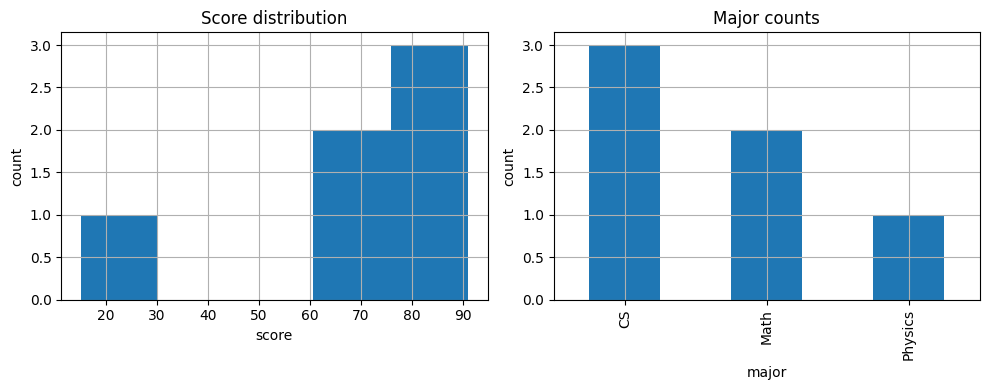

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for a numeric column (score)
axes[0].hist(df["score"].dropna(), bins=5)
axes[0].set_title("Score distribution")
axes[0].set_xlabel("score")
axes[0].set_ylabel("count")

# Bar chart for a categorical column (major)
df["major"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Major counts")
axes[1].set_xlabel("major")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Step 7: Compare variables to each other

Now we look at the correlations between columns.

For tabular data, some common questions are:
- Does A relate to B? (*numeric* vs *numeric*)
- Are some categories in column C associated with higher values in column D? (*categorical* vs *numeric*)

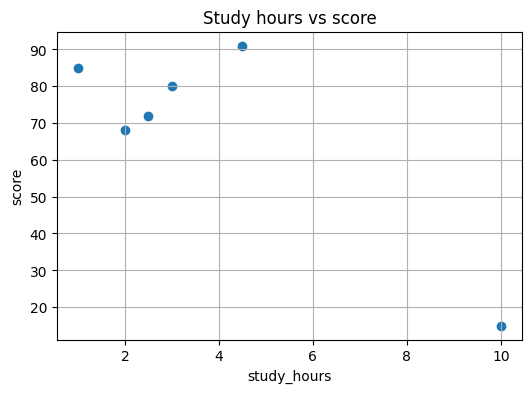

In [65]:
# Scatter plot for two numeric columns.
plt.figure(figsize=(6, 4))
plt.scatter(df["study_hours"], df["score"])
plt.title("Study hours vs score")
plt.xlabel("study_hours")
plt.ylabel("score")
plt.show()

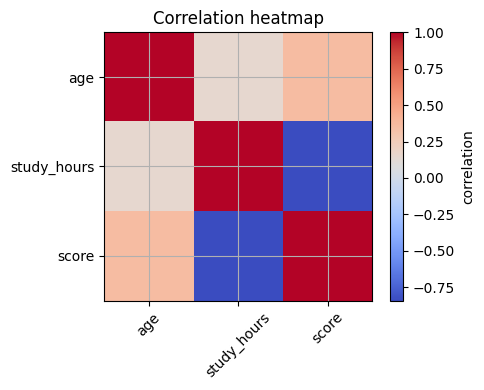

,age,study_hours,score
age,1.000000,0.150197,0.355476
study_hours,0.150197,1.000000,-0.842520
score,0.355476,-0.842520,1.000000


In [66]:
# Correlation matrix for numeric columns.

numeric_df = df[["age", "study_hours", "score"]]
corr = numeric_df.corr()

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

display(corr)

## Step 8: Detect outliers with box plots

A **box plot** is one of the best tools to detect outliers.

It shows:
- median (middle value)
- quartiles (spread of the data)
- potential outliers (points far away from the rest)

Outliers are usually values that are much larger or smaller than the majority of the data.

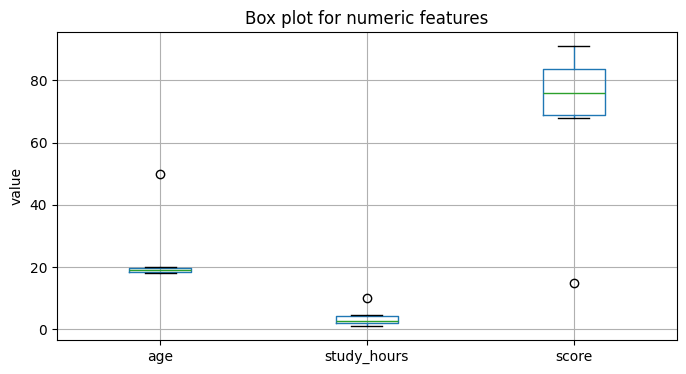

In [67]:
# Create a box plot for numeric columns.

numeric_cols = ["age", "study_hours", "score"]

plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()

plt.title("Box plot for numeric features")
plt.ylabel("value")
plt.show()

## How to read the box plot

- The **box** shows the middle 50% of the data (interquartile range)
- The **line inside the box** is the median
- The **whiskers** extend within 1.5 × IQR from Q1 and Q3, showing variability outside the middle 50%.
- Points outside the whiskers are **potential outliers**

If you see points far away from the box, investigate them.

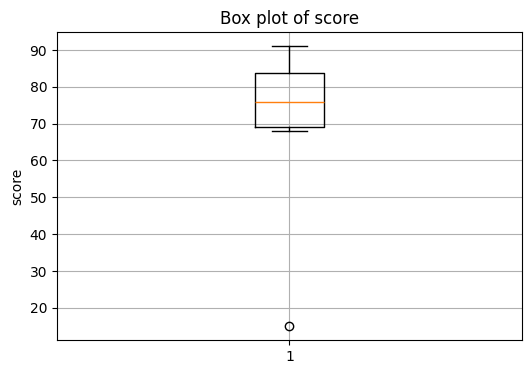

In [68]:
# Look at one column more closely.

plt.figure(figsize=(6, 4))
plt.boxplot(df["score"].dropna())

plt.title("Box plot of score")
plt.ylabel("score")
plt.show()

In [69]:
# Identify outliers for "score" column using the IQR rule

Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Any value below the lower bound or above the upper bound is a outlier
outliers = df[(df["score"] < lower_bound) | (df["score"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nPotential outliers:")
display(outliers)

Lower bound: 46.875
Upper bound: 105.875

Potential outliers:


,student_id,age,study_hours,score,major
7,7,20.0,10.0,15,CS


## Why plotting matters - a Datasaurus Dozen example

The Datasaurus Dozen is a famous reminder that different datasets can have very similar summary statistics, even though their shapes are completely different.

That means:
- mean may look the same
- standard deviation may look similar
- correlation may look similar

But the plot can tell a very different story.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file.
# Adjust the path if needed.
df = pd.read_csv("/workspaces/cats-and-dogs-faces-ex/labs/datasaurus.csv")

print("Shape:", df.shape)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/cats-and-dogs-faces-ex/labs/datasaurus.csv'

In [71]:
# Check the column names and data types.

print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns: ['filepath', 'label', 'split', 'width', 'height', 'mean_intensity']

Data types:
filepath              str
label                 str
split                 str
width               int64
height              int64
mean_intensity    float64
dtype: object

Missing values:
filepath          0
label             0
split             0
width             0
height            0
mean_intensity    0
dtype: int64


In [72]:
# Overall summary statistics for x and y.

display(df[["x", "y"]].describe())

KeyError: "None of [Index(['x', 'y'], dtype='str')] are in the [columns]"

In [ ]:
# Summary statistics for each dataset group. 
# As you can see, all the groups have the same summary statistics..

group_stats = df.groupby("dataset")[["x", "y"]].agg(["mean", "std", "min", "max", "median"])
display(group_stats)

In [ ]:
# Plot all datasets in a grid.

datasets = df["dataset"].unique()
n_plots = len(datasets)
ncols = 4
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, datasets):
    subset = df[df["dataset"] == name]
    ax.scatter(subset["x"], subset["y"], s=10)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

# Hide unused subplots
for ax in axes[n_plots:]:
    ax.axis("off")

plt.suptitle("Datasaurus Dozen", fontsize=16)
plt.tight_layout()
plt.show()

### Reflection

The summary statistics may look similar across datasets, but the plots can be very different.

This is why EDA should always include both:
- numerical summaries
- visual inspection